<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16 Convnet Experiments

## Exercises 16.1 and 16.4

This notebook contains two related convolutional-neural-network experiments:

- **Exercise 16.1:** Adapt the chapter's MNIST CNN to Fashion-MNIST and compare the two datasets.
- **Exercise 16.4:** Remove the chapter model's first dense layer, then test a 4096-neuron dense layer and compare both modifications with the original model.

## Runtime Setup

In Google Colab, select **Runtime → Change runtime type → T4 GPU**, then select **Runtime → Run all**. The complete notebook trains five CNNs, including one model with a 4096-neuron dense layer.

In [1]:
%pip install -q tensorflow matplotlib scikit-learn

# Exercise 16.1 — Image Recognition with Fashion-MNIST

## Imports and Reproducibility

In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import fashion_mnist, mnist
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras.utils import to_categorical

SEED = 11
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part 1 — Fashion-MNIST

Fashion-MNIST contains 60,000 training images and 10,000 testing images. Each image is 28 × 28 pixels in grayscale and belongs to one of ten clothing categories.

## Load Fashion-MNIST

In [3]:
(fashion_X_train_raw, fashion_y_train_raw), (fashion_X_test_raw, fashion_y_test_raw) = fashion_mnist.load_data()

fashion_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Training images:', fashion_X_train_raw.shape)
print('Training labels:', fashion_y_train_raw.shape)
print('Testing images: ', fashion_X_test_raw.shape)
print('Testing labels: ', fashion_y_test_raw.shape)
print('Pixel range:', fashion_X_train_raw.min(), 'to', fashion_X_train_raw.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images:  (10000, 28, 28)
Testing labels:  (10000,)
Pixel range: 0 to 255


## Display Fashion-MNIST Samples

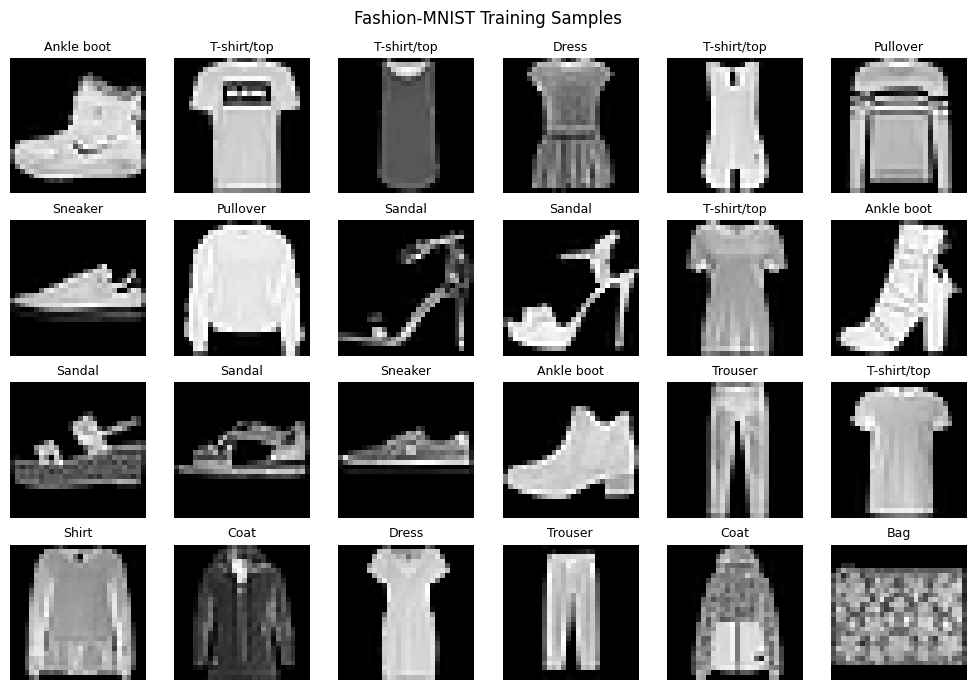

In [4]:
figure, axes = plt.subplots(4, 6, figsize=(10, 7))
for index, axis in enumerate(axes.flat):
    axis.imshow(fashion_X_train_raw[index], cmap='gray')
    axis.set_title(fashion_class_names[fashion_y_train_raw[index]], fontsize=9)
    axis.axis('off')
figure.suptitle('Fashion-MNIST Training Samples')
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=180, bbox_inches='tight')
plt.show()

## Reshape, Normalize, and One-Hot Encode

In [5]:
def prepare_images_and_labels(X_train, y_train, X_test, y_test):
    X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
    X_test = X_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
    y_train_categorical = to_categorical(y_train, num_classes=10)
    y_test_categorical = to_categorical(y_test, num_classes=10)
    return X_train, y_train_categorical, X_test, y_test_categorical

(
    fashion_X_train, fashion_y_train,
    fashion_X_test, fashion_y_test,
) = prepare_images_and_labels(
    fashion_X_train_raw, fashion_y_train_raw,
    fashion_X_test_raw, fashion_y_test_raw,
)

print('Prepared training images:', fashion_X_train.shape)
print('Prepared testing images: ', fashion_X_test.shape)
print('Prepared training labels:', fashion_y_train.shape)
print('Normalized pixel range:', fashion_X_train.min(), 'to', fashion_X_train.max())

Prepared training images: (60000, 28, 28, 1)
Prepared testing images:  (10000, 28, 28, 1)
Prepared training labels: (60000, 10)
Normalized pixel range: 0.0 to 1.0


## Create the Chapter's Convolutional Neural Network

In [6]:
def create_chapter_cnn():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(units=128, activation='relu'),
        Dense(units=10, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

fashion_cnn = create_chapter_cnn()
fashion_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Fashion-MNIST Model and Measure Time

In [7]:
start = perf_counter()
fashion_history = fashion_cnn.fit(
    fashion_X_train,
    fashion_y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)
fashion_training_seconds = perf_counter() - start

print(f'Fashion-MNIST training time: {fashion_training_seconds:.2f} seconds')

Epoch 1/5
844/844 - 14s - 17ms/step - accuracy: 0.8312 - loss: 0.4638 - val_accuracy: 0.8820 - val_loss: 0.3281
Epoch 2/5
844/844 - 4s - 4ms/step - accuracy: 0.8885 - loss: 0.3034 - val_accuracy: 0.8950 - val_loss: 0.2858
Epoch 3/5
844/844 - 4s - 5ms/step - accuracy: 0.9069 - loss: 0.2550 - val_accuracy: 0.9030 - val_loss: 0.2643
Epoch 4/5
844/844 - 4s - 5ms/step - accuracy: 0.9186 - loss: 0.2213 - val_accuracy: 0.9065 - val_loss: 0.2568
Epoch 5/5
844/844 - 4s - 4ms/step - accuracy: 0.9307 - loss: 0.1908 - val_accuracy: 0.9080 - val_loss: 0.2595
Fashion-MNIST training time: 31.01 seconds


## Evaluate Fashion-MNIST

In [8]:
fashion_test_loss, fashion_test_accuracy = fashion_cnn.evaluate(
    fashion_X_test, fashion_y_test, verbose=0
)
fashion_probabilities = fashion_cnn.predict(fashion_X_test, verbose=0)
fashion_predictions = np.argmax(fashion_probabilities, axis=1)

print(f'Fashion-MNIST test loss: {fashion_test_loss:.4f}')
print(f'Fashion-MNIST test accuracy: {fashion_test_accuracy:.4f} '      f'({fashion_test_accuracy:.2%})')
print('Fashion-MNIST confusion matrix:')
print(confusion_matrix(fashion_y_test_raw, fashion_predictions))

Fashion-MNIST test loss: 0.2723
Fashion-MNIST test accuracy: 0.9038 (90.38%)
Fashion-MNIST confusion matrix:
[[852   0  20   5   5   1 114   0   3   0]
 [  5 981   1   8   2   0   2   0   1   0]
 [ 13   0 852   5  62   0  68   0   0   0]
 [ 28   9  12 854  53   0  43   0   1   0]
 [  1   1  42  10 877   0  69   0   0   0]
 [  0   0   0   0   0 980   0  18   0   2]
 [113   3  42  13  60   0 761   0   8   0]
 [  0   0   0   0   0   9   0 985   0   6]
 [  3   1   3   0   6   3   7   4 973   0]
 [  1   0   0   0   0  10   0  66   0 923]]


## Fashion-MNIST Classification Report

In [9]:
print(classification_report(
    fashion_y_test_raw,
    fashion_predictions,
    target_names=fashion_class_names,
))

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.88      0.85      0.86      1000
       Dress       0.95      0.85      0.90      1000
        Coat       0.82      0.88      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.76      0.74      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.99      0.92      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



## Visualize Incorrect Fashion-MNIST Predictions

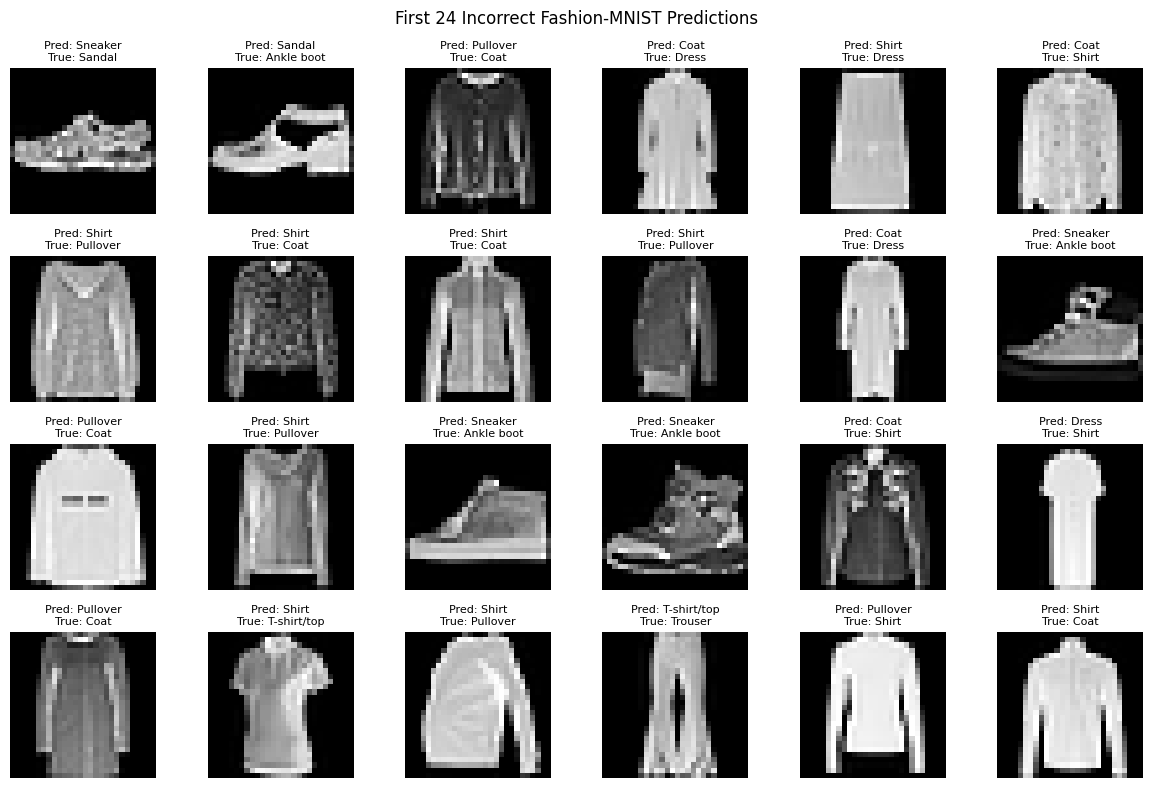

In [10]:
incorrect_indices = np.flatnonzero(fashion_predictions != fashion_y_test_raw)[:24]
figure, axes = plt.subplots(4, 6, figsize=(12, 8))
for axis, index in zip(axes.flat, incorrect_indices):
    axis.imshow(fashion_X_test_raw[index], cmap='gray')
    predicted_name = fashion_class_names[fashion_predictions[index]]
    actual_name = fashion_class_names[fashion_y_test_raw[index]]
    axis.set_title(f'Pred: {predicted_name}\nTrue: {actual_name}', fontsize=8)
    axis.axis('off')
figure.suptitle('First 24 Incorrect Fashion-MNIST Predictions')
plt.tight_layout()
plt.savefig('fashion_mnist_incorrect_predictions.png', dpi=180, bbox_inches='tight')
plt.show()

# Part 2 — Train the Same CNN on MNIST

In [11]:
(mnist_X_train_raw, mnist_y_train_raw), (mnist_X_test_raw, mnist_y_test_raw) = mnist.load_data()

mnist_X_train, mnist_y_train, mnist_X_test, mnist_y_test = prepare_images_and_labels(
    mnist_X_train_raw, mnist_y_train_raw,
    mnist_X_test_raw, mnist_y_test_raw,
)

# Reapply the same seed before constructing the comparison model.
tf.keras.utils.set_random_seed(SEED)
mnist_cnn = create_chapter_cnn()

start = perf_counter()
mnist_history = mnist_cnn.fit(
    mnist_X_train,
    mnist_y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)
mnist_training_seconds = perf_counter() - start

mnist_test_loss, mnist_test_accuracy = mnist_cnn.evaluate(
    mnist_X_test, mnist_y_test, verbose=0
)

print(f'MNIST training time: {mnist_training_seconds:.2f} seconds')
print(f'MNIST test loss: {mnist_test_loss:.4f}')
print(f'MNIST test accuracy: {mnist_test_accuracy:.4f} ({mnist_test_accuracy:.2%})')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
844/844 - 8s - 10ms/step - accuracy: 0.9560 - loss: 0.1417 - val_accuracy: 0.9877 - val_loss: 0.0445
Epoch 2/5
844/844 - 4s - 5ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9892 - val_loss: 0.0381
Epoch 3/5
844/844 - 5s - 6ms/step - accuracy: 0.9919 - loss: 0.0257 - val_accuracy: 0.9898 - val_loss: 0.0381
Epoch 4/5
844/844 - 4s - 4ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9905 - val_loss: 0.0400
Epoch 5/5
844/844 - 4s - 5ms/step - accuracy: 0.9954 - loss: 0.0140 - val_accuracy: 0.9892 - val_loss: 0.0400
MNIST training time: 25.93 seconds
MNIST test loss: 0.0336
MNIST test accuracy: 0.9905 (99.05%)


# Part 3 — Compare Performance and Training Time

In [12]:
accuracy_difference = fashion_test_accuracy - mnist_test_accuracy
time_difference = fashion_training_seconds - mnist_training_seconds
time_ratio = fashion_training_seconds / mnist_training_seconds

print(f"{'Dataset':<18}{'Test accuracy':>16}{'Training time (s)':>20}")
print('-' * 54)
print(f"{'MNIST':<18}{mnist_test_accuracy:>16.4f}{mnist_training_seconds:>20.2f}")
print(f"{'Fashion-MNIST':<18}{fashion_test_accuracy:>16.4f}{fashion_training_seconds:>20.2f}")

print(f'\nFashion-MNIST accuracy difference: {accuracy_difference:+.4f} '      f'({accuracy_difference:+.2%})')
print(f'Fashion-MNIST training-time difference: {time_difference:+.2f} seconds')
print(f'Fashion-MNIST/MNIST training-time ratio: {time_ratio:.2f}x')

Dataset              Test accuracy   Training time (s)
------------------------------------------------------
MNIST                       0.9905               25.93
Fashion-MNIST               0.9038               31.01

Fashion-MNIST accuracy difference: -0.0867 (-8.67%)
Fashion-MNIST training-time difference: +5.09 seconds
Fashion-MNIST/MNIST training-time ratio: 1.20x


## Accuracy and Training-Time Comparison Charts

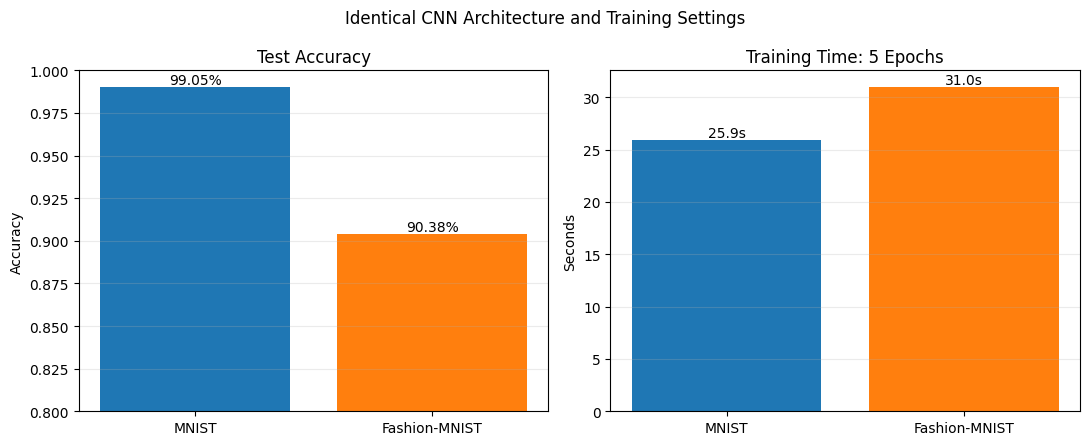

In [13]:
dataset_names = ['MNIST', 'Fashion-MNIST']
accuracy_values = [mnist_test_accuracy, fashion_test_accuracy]
training_times = [mnist_training_seconds, fashion_training_seconds]

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))

accuracy_bars = axes[0].bar(dataset_names, accuracy_values, color=['tab:blue', 'tab:orange'])
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.80, 1.00)
axes[0].bar_label(accuracy_bars, labels=[f'{value:.2%}' for value in accuracy_values])
axes[0].grid(axis='y', alpha=0.25)

time_bars = axes[1].bar(dataset_names, training_times, color=['tab:blue', 'tab:orange'])
axes[1].set_title('Training Time: 5 Epochs')
axes[1].set_ylabel('Seconds')
axes[1].bar_label(time_bars, labels=[f'{value:.1f}s' for value in training_times])
axes[1].grid(axis='y', alpha=0.25)

figure.suptitle('Identical CNN Architecture and Training Settings')
plt.tight_layout()
plt.savefig('mnist_fashion_mnist_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Learning Curves

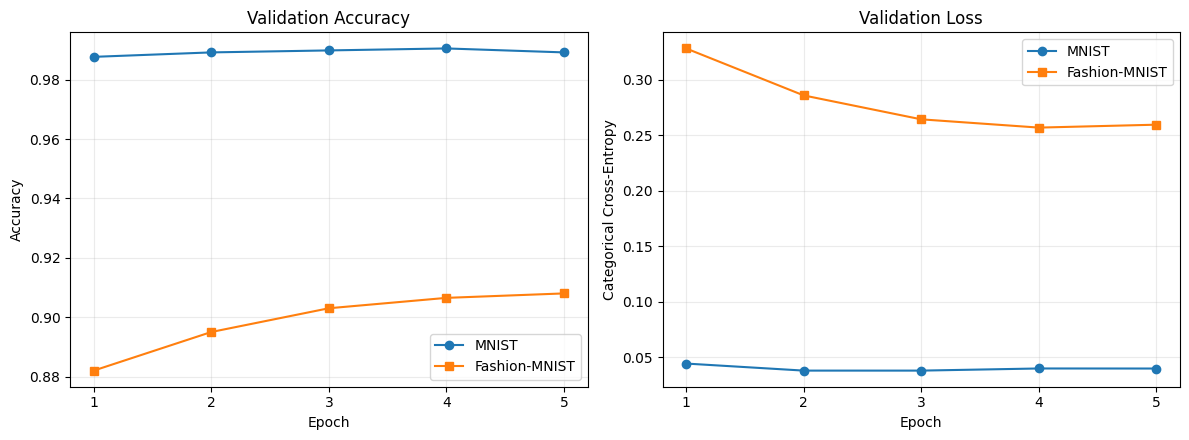

In [14]:
epochs = range(1, 6)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs, mnist_history.history['val_accuracy'], marker='o', label='MNIST')
axes[0].plot(epochs, fashion_history.history['val_accuracy'], marker='s', label='Fashion-MNIST')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(list(epochs))
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(epochs, mnist_history.history['val_loss'], marker='o', label='MNIST')
axes[1].plot(epochs, fashion_history.history['val_loss'], marker='s', label='Fashion-MNIST')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].set_xticks(list(epochs))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig('mnist_fashion_mnist_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

## Conclusion

Fashion-MNIST normally produces lower accuracy than MNIST with this CNN because clothing classes contain more visual overlap—for example, shirts, coats, pullovers, and T-shirts are more easily confused than handwritten digits. Training times should be similar because both datasets contain the same number of 28 × 28 grayscale images and use identical model and training settings. Small timing differences are expected from hardware load, GPU warm-up, and normal runtime variation. Use the measured values printed above as the final answer for this run.

# Exercise 16.4 — Convnet Layers

The following experiment returns to MNIST and compares the original chapter model with two dense-layer modifications. It deliberately reinitializes every model with the same seed and trains each for the same five epochs.

## Imports and Reproducibility

In [15]:
import gc
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras.utils import to_categorical

SEED = 11
EPOCHS = 5
BATCH_SIZE = 64

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load and Prepare MNIST

In [16]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
X_test = X_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print('Training images:', X_train.shape)
print('Training labels:', y_train.shape)
print('Testing images: ', X_test.shape)
print('Testing labels: ', y_test.shape)
print('Normalized pixel range:', X_train.min(), 'to', X_train.max())

Training images: (60000, 28, 28, 1)
Training labels: (60000, 10)
Testing images:  (10000, 28, 28, 1)
Testing labels:  (10000, 10)
Normalized pixel range: 0.0 to 1.0


## Define the Three CNN Variants

In [17]:
def create_cnn(variant):
    layers = [
        Input(shape=(28, 28, 1)),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
    ]

    if variant == 'large_4096':
        # Added before both Dense layers in the chapter model.
        layers.append(Dense(units=4096, activation='relu'))

    if variant != 'removed_128':
        # The chapter model's first Dense layer.
        layers.append(Dense(units=128, activation='relu'))

    layers.append(Dense(units=10, activation='softmax'))

    model = Sequential(layers)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

## Confirm the Architectures and Parameter Counts

In [18]:
variant_labels = {
    'baseline': 'Baseline Dense(128)',
    'removed_128': 'Dense(128) removed',
    'large_4096': 'Dense(4096) added',
}

parameter_counts = {}
for variant, label in variant_labels.items():
    tf.keras.backend.clear_session()
    model = create_cnn(variant)
    parameter_counts[variant] = model.count_params()
    print(f'{label:<24}: {model.count_params():>12,} parameters')

tf.keras.backend.clear_session()
del model
gc.collect()

Baseline Dense(128)     :      485,514 parameters
Dense(128) removed      :      106,506 parameters
Dense(4096) added       :   13,711,498 parameters


1310

## Training Function

In [19]:
def train_and_evaluate(variant):
    # Release the preceding model before constructing the next one.
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(SEED)

    model = create_cnn(variant)
    print(f'\nTraining: {variant_labels[variant]}')
    model.summary()

    start = perf_counter()
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=2,
    )
    training_seconds = perf_counter() - start

    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    return {
        'parameters': model.count_params(),
        'training_seconds': training_seconds,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'history': {key: list(values) for key, values in history.history.items()},
    }

## 1. Train the Chapter's Baseline Model

In [20]:
results = {}
results['baseline'] = train_and_evaluate('baseline')

print(f"Baseline test accuracy: {results['baseline']['test_accuracy']:.4f} "
      f"({results['baseline']['test_accuracy']:.2%})")
print(f"Baseline training time: {results['baseline']['training_seconds']:.2f} seconds")


Training: Baseline Dense(128)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 - 9s - 10ms/step - accuracy: 0.9561 - loss: 0.1416 - val_accuracy: 0.9862 - val_loss: 0.0456
Epoch 2/5
844/844 - 4s - 5ms/step - accuracy: 0.9869 - loss: 0.0411 - val_accuracy: 0.9885 - val_loss: 0.0370
Epoch 3/5
844/844 - 4s - 4ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9892 - val_loss: 0.0366
Epoch 4/5
844/844 - 4s - 5ms/step - accuracy: 0.9946 - loss: 0.0177 - val_accuracy: 0.9882 - val_loss: 0.0397
Epoch 5/5
844/844 - 5s - 6ms/step - accuracy: 0.9957 - loss: 0.0139 - val_accuracy: 0.9900 - val_loss: 0.0423
Baseline test accuracy: 0.9897 (98.97%)
Baseline training time: 25.59 seconds


## 2. Remove the First Dense Layer

In [21]:
results['removed_128'] = train_and_evaluate('removed_128')

removed_change = (
    results['removed_128']['test_accuracy']
    - results['baseline']['test_accuracy']
)
print(f"No-Dense test accuracy: {results['removed_128']['test_accuracy']:.4f} "
      f"({results['removed_128']['test_accuracy']:.2%})")
print(f'Accuracy change from baseline: {removed_change:+.4f} ({removed_change:+.2%})')
print(f"Training time: {results['removed_128']['training_seconds']:.2f} seconds")


Training: Dense(128) removed


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,506 (416.04 KB)

 Trainable params: 106,506 (416.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 - 9s - 10ms/step - accuracy: 0.9504 - loss: 0.1712 - val_accuracy: 0.9830 - val_loss: 0.0577
Epoch 2/5
844/844 - 4s - 4ms/step - accuracy: 0.9836 - loss: 0.0527 - val_accuracy: 0.9885 - val_loss: 0.0419
Epoch 3/5
844/844 - 4s - 5ms/step - accuracy: 0.9892 - loss: 0.0363 - val_accuracy: 0.9893 - val_loss: 0.0375
Epoch 4/5
844/844 - 4s - 4ms/step - accuracy: 0.9922 - loss: 0.0261 - val_accuracy: 0.9903 - val_loss: 0.0363
Epoch 5/5
844/844 - 4s - 4ms/step - accuracy: 0.9941 - loss: 0.0199 - val_accuracy: 0.9898 - val_loss: 0.0381
No-Dense test accuracy: 0.9883 (98.83%)
Accuracy change from baseline: -0.0014 (-0.14%)
Training time: 24.27 seconds


## 3. Add a 4096-Neuron Dense Layer

In [22]:
results['large_4096'] = train_and_evaluate('large_4096')

large_change = (
    results['large_4096']['test_accuracy']
    - results['baseline']['test_accuracy']
)
print(f"4096-layer test accuracy: {results['large_4096']['test_accuracy']:.4f} "
      f"({results['large_4096']['test_accuracy']:.2%})")
print(f'Accuracy change from baseline: {large_change:+.4f} ({large_change:+.2%})')
print(f"Training time: {results['large_4096']['training_seconds']:.2f} seconds")


Training: Dense(4096) added


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    13,111,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,711,498 (52.31 MB)

 Trainable params: 13,711,498 (52.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 - 12s - 14ms/step - accuracy: 0.9634 - loss: 0.1171 - val_accuracy: 0.9898 - val_loss: 0.0379
Epoch 2/5
844/844 - 6s - 8ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 3/5
844/844 - 6s - 8ms/step - accuracy: 0.9926 - loss: 0.0239 - val_accuracy: 0.9887 - val_loss: 0.0390
Epoch 4/5
844/844 - 6s - 8ms/step - accuracy: 0.9942 - loss: 0.0188 - val_accuracy: 0.9897 - val_loss: 0.0403
Epoch 5/5
844/844 - 7s - 8ms/step - accuracy: 0.9954 - loss: 0.0148 - val_accuracy: 0.9930 - val_loss: 0.0330
4096-layer test accuracy: 0.9911 (99.11%)
Accuracy change from baseline: +0.0014 (+0.14%)
Training time: 38.69 seconds


## Results Table

In [23]:
print(f"{'Model':<24}{'Parameters':>14}{'Test accuracy':>17}{'Train time (s)':>17}")
print('-' * 72)
for variant, label in variant_labels.items():
    result = results[variant]
    print(
        f"{label:<24}{result['parameters']:>14,}"
        f"{result['test_accuracy']:>17.4f}{result['training_seconds']:>17.2f}"
    )

best_variant = max(results, key=lambda key: results[key]['test_accuracy'])
print(f'Highest test accuracy: {variant_labels[best_variant]} '      f"({results[best_variant]['test_accuracy']:.2%})")

Model                       Parameters    Test accuracy   Train time (s)
------------------------------------------------------------------------
Baseline Dense(128)            485,514           0.9897            25.59
Dense(128) removed             106,506           0.9883            24.27
Dense(4096) added           13,711,498           0.9911            38.69
Highest test accuracy: Dense(4096) added (99.11%)


## Accuracy and Training-Time Comparison

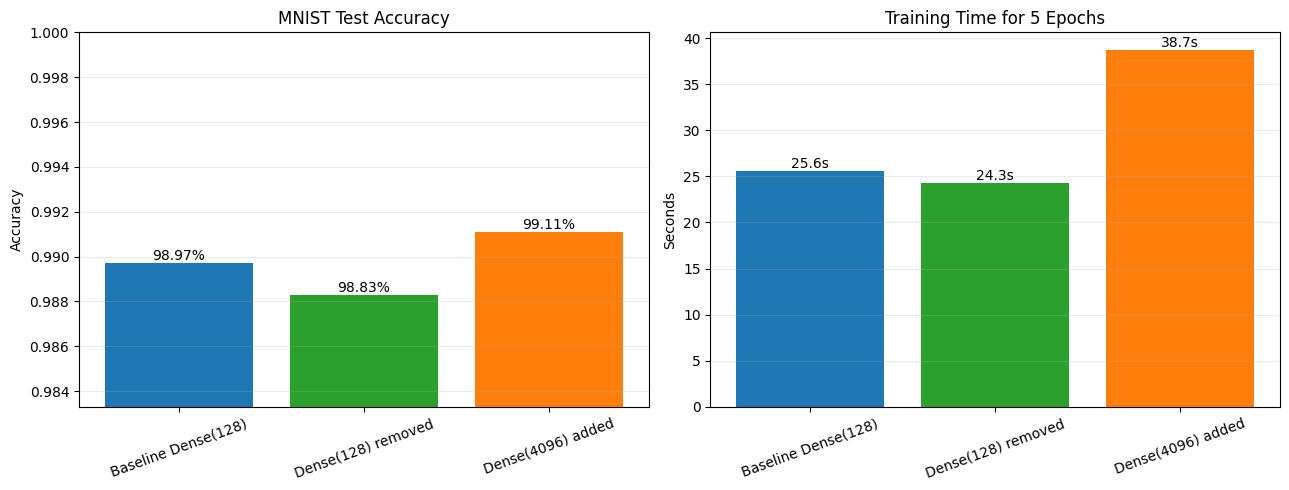

In [24]:
variants = list(variant_labels)
labels = [variant_labels[variant] for variant in variants]
accuracies = [results[variant]['test_accuracy'] for variant in variants]
training_times = [results[variant]['training_seconds'] for variant in variants]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

accuracy_bars = axes[0].bar(labels, accuracies, color=['tab:blue', 'tab:green', 'tab:orange'])
axes[0].set_title('MNIST Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(min(accuracies) - 0.005, 1.0)
axes[0].tick_params(axis='x', rotation=20)
axes[0].bar_label(accuracy_bars, labels=[f'{value:.2%}' for value in accuracies])
axes[0].grid(axis='y', alpha=0.25)

time_bars = axes[1].bar(labels, training_times, color=['tab:blue', 'tab:green', 'tab:orange'])
axes[1].set_title('Training Time for 5 Epochs')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar_label(time_bars, labels=[f'{value:.1f}s' for value in training_times])
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('convnet_dense_layer_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## Validation Learning Curves

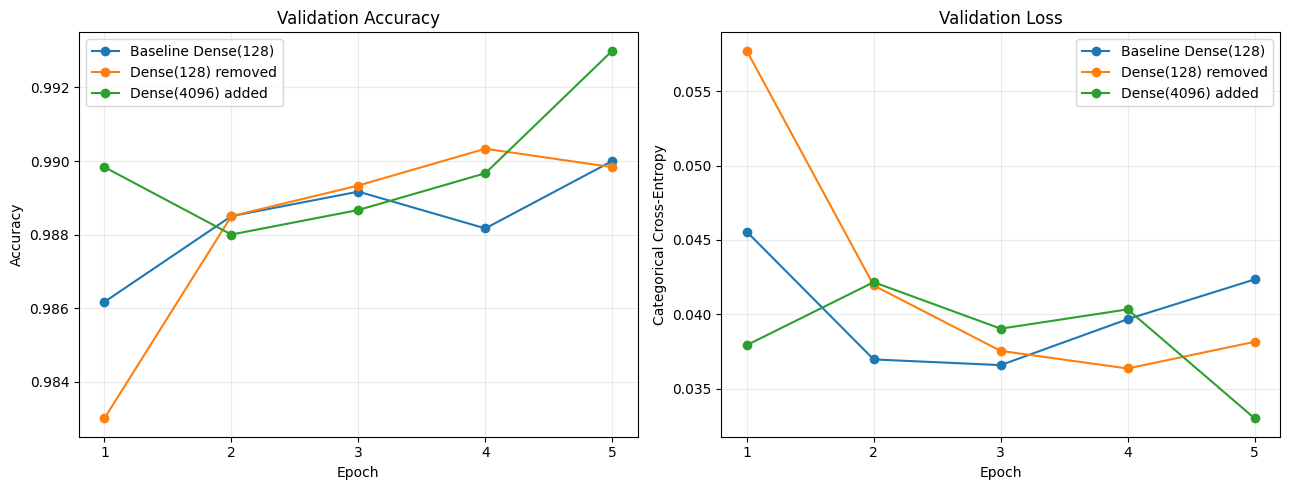

In [25]:
epochs = range(1, EPOCHS + 1)
figure, axes = plt.subplots(1, 2, figsize=(13, 5))

for variant, label in variant_labels.items():
    axes[0].plot(
        epochs, results[variant]['history']['val_accuracy'], marker='o', label=label
    )
    axes[1].plot(
        epochs, results[variant]['history']['val_loss'], marker='o', label=label
    )

axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(list(epochs))
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].set_xticks(list(epochs))
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig('convnet_dense_layer_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()

## Interpretation

Removing `Dense(128)` reduces the model from about 486 thousand parameters to about 107 thousand. Accuracy may decline slightly because the output layer receives fewer learned high-level combinations of the convolutional features, though MNIST is simple enough that the reduction can be small.

Adding `Dense(4096)` increases the model to roughly 13.7 million parameters. This greatly increases computation and memory use, but it does not guarantee better test accuracy. The larger model may produce a small improvement, no meaningful change, or slightly worse generalization through overfitting. The measured accuracy differences printed above are the answer for this run.